In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


In [72]:
## load dataset
df = pd.read_csv('/content/athletes_data_raw.csv') ## represents the athlete dataset
df2= pd.read_csv('/content/medalists_data_raw.csv') ## represents medalists dataset

In [73]:
## preview
df.head()


,id,name,gender,born,died,height,weight,team,game,noc,sport,event,medal
0,131892,Meryem Erdoğan,Female,24 April 1990,NaN,172 cm,55 kg,Türkiye,2016 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
1,131892,Meryem Erdoğan,Female,24 April 1990,NaN,172 cm,55 kg,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
2,131892,Meryem Erdoğan,Female,24 April 1990,NaN,172 cm,55 kg,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
3,4300,Maurice Maina,Male,1 January 1963,NaN,158 cm,47 kg,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN
4,4300,Maurice Maina,Male,1 January 1963,NaN,158 cm,47 kg,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN


In [74]:
df2.head()

,Year,medal,medal_code,name,gender,noc,country,Type,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,discipline,event,event_type,url_event,Unnamed: 17,code_athlete,Unnamed: 19,is_medallist
0,2024,Gold,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Summer Olympics,NaN,NaN,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,NaN,1903136,NaN,True
1,2024,Silver,2.0,GANNA Filippo,Male,ITA,Italy,Summer Olympics,NaN,NaN,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,NaN,1923520,NaN,True
2,2024,Bronze,3.0,van AERT Wout,Male,BEL,Belgium,Summer Olympics,NaN,NaN,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,NaN,1903147,NaN,True
3,2024,Gold,1.0,BROWN Grace,Female,AUS,Australia,Summer Olympics,NaN,NaN,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,NaN,1940173,NaN,True
4,2024,Silver,2.0,HENDERSON Anna,Female,GBR,Great Britain,Summer Olympics,NaN,NaN,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,NaN,1912525,NaN,True


In [75]:
## cleaning data

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476348 entries, 0 to 476347
Data columns (total 13 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      476348 non-null  int64 
 1   name    476348 non-null  object
 2   gender  476348 non-null  object
 3   born    467032 non-null  object
 4   died    116593 non-null  object
 5   height  348837 non-null  object
 6   weight  340019 non-null  object
 7   team    476348 non-null  object
 8   game    476348 non-null  object
 9   noc     476348 non-null  object
 10  sport   476348 non-null  object
 11  event   476348 non-null  object
 12  medal   66026 non-null   object
dtypes: int64(1), object(12)
memory usage: 47.2+ MB


In [76]:
df.isnull().sum()

,0
id,0
name,0
gender,0
born,9316
died,359755
height,127511
weight,136329
team,0
game,0
noc,0


In [77]:
## dropping born ,died, height, weight colums as not needed in analysis.
columns_to_drop = ['born', 'died', 'height', 'weight']
for column in columns_to_drop:
    if column in df.columns:
        df = df.drop(columns=column)


In [78]:
## drop the empty columns from df2
df2.dropna(axis=1, how='all', inplace=True)
df2.head()

,Year,medal,medal_code,name,gender,noc,country,Type,discipline,event,event_type,url_event,code_athlete,is_medallist
0,2024,Gold,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Summer Olympics,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903136,True
1,2024,Silver,2.0,GANNA Filippo,Male,ITA,Italy,Summer Olympics,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1923520,True
2,2024,Bronze,3.0,van AERT Wout,Male,BEL,Belgium,Summer Olympics,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903147,True
3,2024,Gold,1.0,BROWN Grace,Female,AUS,Australia,Summer Olympics,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1940173,True
4,2024,Silver,2.0,HENDERSON Anna,Female,GBR,Great Britain,Summer Olympics,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1912525,True


In [106]:
duplicate_rows = df[df.duplicated()]
number_of_duplicates = duplicate_rows.shape[0]
print(f"Number of duplicate rows: {number_of_duplicates}")

Number of duplicate rows: 157387


In [88]:
## as we are analysing 2 different types of olympic, summer and winter extracting the year and type of olympics from game column
df1 = df.copy()

## as we are analysing 2 different types of olympic, summer and winter extracting the year and type of olympics from game column
df1['Year'] = df1['game'].str.extract(R'(\d{4})').astype(int)
df1.head()

df1['Type'] = df1['game'].str.extract(R'(\D+)').astype(str)
df1.head()


,id,name,gender,team,game,noc,sport,event,medal,Year,Type
0,131892,Meryem Erdoğan,Female,Türkiye,2016 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN,2016,Summer Olympics
1,131892,Meryem Erdoğan,Female,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN,2020,Summer Olympics
2,131892,Meryem Erdoğan,Female,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN,2020,Summer Olympics
3,4300,Maurice Maina,Male,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN,1988,Summer Olympics
4,4300,Maurice Maina,Male,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN,1988,Summer Olympics


In [89]:
# for better representation of data moving Year column and make as first column

# inplace the changes done on this dataset
df1.insert(1, 'Year', df1.pop('Year'))

## also moving Type in between Year and name column
df1.insert(2, 'Type', df1.pop('Type'))
df1.head()

,id,Year,Type,name,gender,team,game,noc,sport,event,medal
0,131892,2016,Summer Olympics,Meryem Erdoğan,Female,Türkiye,2016 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
1,131892,2020,Summer Olympics,Meryem Erdoğan,Female,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
2,131892,2020,Summer Olympics,Meryem Erdoğan,Female,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
3,4300,1988,Summer Olympics,Maurice Maina,Male,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN
4,4300,1988,Summer Olympics,Maurice Maina,Male,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN


In [90]:
# Combine the two DataFrames
new_df = pd.concat([df1, df2], ignore_index=True)

# Optionally, you might want to sort the data by a specific column (e.g., date)
new_df.sort_values(by='Year', inplace=True)

# Save the combined DataFrame to a new file
new_df.to_csv('combined_data.csv', index=False)

print("Data combined successfully!")


Data combined successfully!


In [91]:
# remove duplicates if any
new_df.drop_duplicates(subset=['name','event','Year'])
new_df.head()

,id,Year,Type,name,gender,team,game,noc,sport,event,medal,medal_code,country,discipline,event_type,url_event,code_athlete,is_medallist
259533,55911.0,1888,-,Sotirios Versis,Male,Greece,1888-89 Zappas Olympic Games,GRE,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Rope Climbin...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339871,30380.0,1896,Summer Olympics,Gyula Kakas,Male,Hungary,1896 Summer Olympics,HUN,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Horizontal B...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217733,30303.0,1896,Summer Olympics,Gustav Schuft,Male,Germany,1896 Summer Olympics,GER,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Parallel Bar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217734,30303.0,1896,Summer Olympics,Gustav Schuft,Male,Germany,1896 Summer Olympics,GER,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Parallel Bar...",Gold,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217735,30303.0,1896,Summer Olympics,Gustav Schuft,Male,Germany,1896 Summer Olympics,GER,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Horizontal B...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# Filter data for the last 20 years (2004–2024)
new_df = new_df[(new_df['Year'] >= 2004) & (new_df['Year'] <= 2024)]
new_df


,id,Year,Type,name,gender,team,game,noc,sport,event,medal,medal_code,country,discipline,event_type,url_event,code_athlete,is_medallist
85035,93120.0,2004,Summer Olympics,Espen Berg-Knutsen,Male,Norway,2004 Summer Olympics,NOR,Shooting,"Shooting, Small-Bore Rifle, Prone, 50 metres, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86100,75250.0,2004,Summer Olympics,Okkert Brits,Male,South Africa,2004 Summer Olympics,RSA,Athletics,"Athletics, Pole Vault, Men(Olympic)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143579,41342.0,2004,Summer Olympics,Lalita Milshina-Yauhleuskaya,Female,Australia Belarus,2004 Summer Olympics,AUS,Shooting,"Shooting, Air Pistol, 10 metres, Women(Olympic)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44601,94506.0,2004,Summer Olympics,Kiki,Female,Brazil,2004 Summer Olympics,BRA,Volleyball (Volleyball),"Volleyball (Volleyball), Volleyball, Women(Oly...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145810,723.0,2004,Summer Olympics,Maggy Maleeva,Female,Bulgaria,2004 Summer Olympics,BUL,Tennis,"Tennis, Singles, Women(Olympic)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477120,NaN,2024,Summer Olympics,JOSEPH Jefferson-Lee,Male,NaN,NaN,FRA,NaN,Men,Gold,1.0,France,Rugby Sevens,HTEAM,/en/paris-2024/results/rugby-sevens/men/fnl-00...,1879675.0,True
477121,NaN,2024,Summer Olympics,ZEGHDAR Antoine,Male,NaN,NaN,FRA,NaN,Men,Gold,1.0,France,Rugby Sevens,HTEAM,/en/paris-2024/results/rugby-sevens/men/fnl-00...,1879692.0,True
477122,NaN,2024,Summer Olympics,GRANDIDIER NKANANG Aaron,Male,NaN,NaN,FRA,NaN,Men,Gold,1.0,France,Rugby Sevens,HTEAM,/en/paris-2024/results/rugby-sevens/men/fnl-00...,1879672.0,True
477070,NaN,2024,Summer Olympics,TYNYBEKOVA Aisuluu,Female,NaN,NaN,KGZ,NaN,Women's Freestyle 62kg,Bronze,3.0,Kyrgyzstan,Wrestling,HATH,/en/paris-2024/results/wrestling/women-s-frees...,1902786.0,True


In [93]:
# Remove leading and trailing spaces in the 'Type' column
new_df['Type'] = new_df['Type'].str.strip()
new_df['Type'].unique()

array(['Summer Olympics', 'Winter Olympics', 'Summer Youth Olympics',
       'Winter Youth Olympics'], dtype=object)

In [94]:
## separating summer and winter olympics
summer_olympics = new_df[new_df['Type'] == 'Summer Olympics']
print("Summer Olympics Data:")
print(summer_olympics.head())


winter_olympics = new_df[new_df['Type'] == 'Winter Olympics']
print("Winter Olympics Data:")
print(winter_olympics.head())


Summer Olympics Data:
             id  Year             Type                          name  gender  \
85035   93120.0  2004  Summer Olympics            Espen Berg-Knutsen    Male   
86100   75250.0  2004  Summer Olympics                  Okkert Brits    Male   
143579  41342.0  2004  Summer Olympics  Lalita Milshina-Yauhleuskaya  Female   
44601   94506.0  2004  Summer Olympics                          Kiki  Female   
145810    723.0  2004  Summer Olympics                 Maggy Maleeva  Female   

                      team                  game  noc  \
85035               Norway  2004 Summer Olympics  NOR   
86100         South Africa  2004 Summer Olympics  RSA   
143579  Australia  Belarus  2004 Summer Olympics  AUS   
44601               Brazil  2004 Summer Olympics  BRA   
145810            Bulgaria  2004 Summer Olympics  BUL   

                          sport  \
85035                  Shooting   
86100                 Athletics   
143579                 Shooting   
44601   Volley

In [95]:
new_df['Type'].unique()

array(['Summer Olympics', 'Winter Olympics', 'Summer Youth Olympics',
       'Winter Youth Olympics'], dtype=object)

In [96]:
## Analysing medals counts by country.
# first for the summer olympics.
summer_medal_counts = summer_olympics.groupby('noc')['medal'].count().reset_index().sort_values(by='medal', ascending=False)
summer_medal_counts.head()

,noc,medal
203,USA,2449
40,CHN,1162
12,AUS,1063
75,GER,995
71,GBR,990


In [97]:
# first for the winter olympics.

winter_medal_counts =winter_olympics.groupby('noc')['medal'].count().reset_index().sort_values(by='medal', ascending=False)
winter_medal_counts.head()

,noc,medal
16,CAN,604
110,USA,495
37,GER,376
33,FIN,317
100,SWE,294


In [98]:
## As per our guiding question display top 10 countries for summer and winter

print("Top 10n countries for Summer Olympics:")
print(summer_medal_counts.head(10))

print("\nTop 10n countries for Winter Olympics:")
print(winter_medal_counts.head(10))

Top 10n countries for Summer Olympics:
     noc  medal
203  USA   2449
40   CHN   1162
12   AUS   1063
75   GER    995
71   GBR    990
67   FRA    903
163  RUS    812
100  JPN    763
96   ITA    638
139  NED    606

Top 10n countries for Winter Olympics:
     noc  medal
16   CAN    604
110  USA    495
37   GER    376
33   FIN    317
100  SWE    294
78   NOR    284
88   ROC    227
7    AUT    182
91   RUS    167
98   SUI    135


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

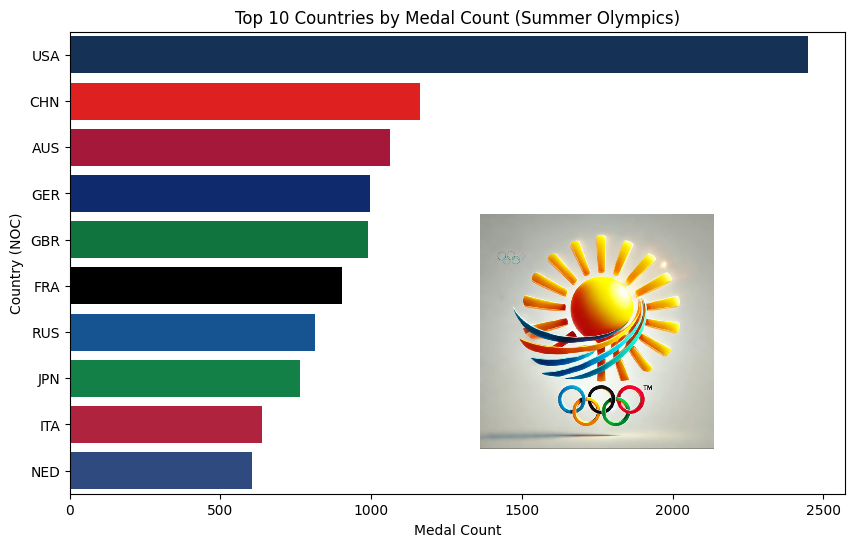

In [99]:
## let's visualize this

# Plot for Summer Olympics

# clours according to flag colour- hex codes
colors = ['#0A3161', '#FF0000', '#BC002D', '#00247D', '#00843D', '#000000', '#0055A4', '#009246', '#C60C30', '#21468B']

plt.figure(figsize=(10, 6))
sns.barplot(x='medal', y='noc', data=summer_medal_counts.head(10), palette= colors,hue='noc', legend=False)
plt.title('Top 10 Countries by Medal Count (Summer Olympics)')
plt.xlabel('Medal Count')
plt.ylabel('Country (NOC)')

# Load the image
img = mpimg.imread('/content/summerlogo.png')  # Replace 'sun.png' with the path to your sun image

# Create the image object and place it on the bar chart
imagebox = OffsetImage(img, zoom= 0.3)
ab = AnnotationBbox(imagebox, (1750, 6), xycoords='data', frameon=False)
ax = plt.gca()
# Add the image to the plot
ax.add_artist(ab)

plt.show()



/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

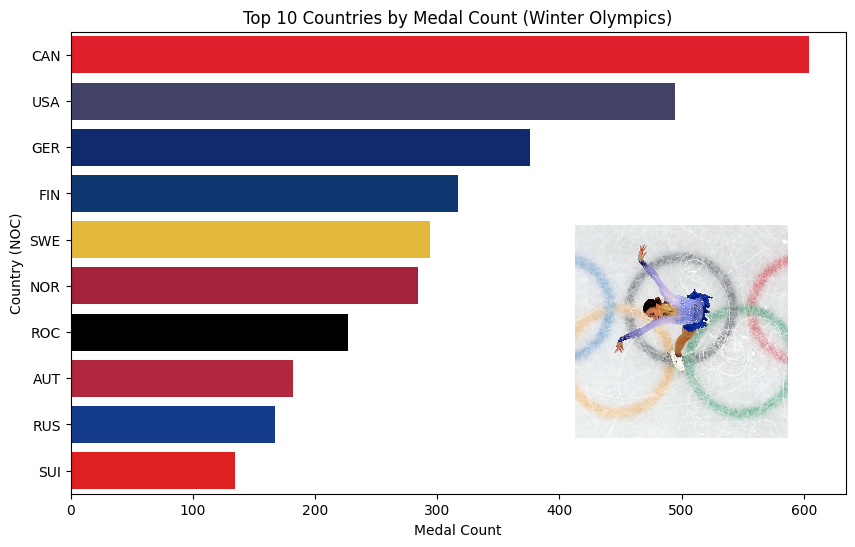

In [101]:
## plot for the winter top 10 medalist countries

winter_colors = ['#FF0010','#3C3B6E','#00247D','#003580','#ffc720','#BA0C2F','#000000','#C8102E','#0033A0','#FF0000']
plt.figure(figsize=(10, 6))
sns.barplot(x='medal', y='noc', data=winter_medal_counts.head(10), palette= winter_colors,hue='noc', legend=False)
plt.title('Top 10 Countries by Medal Count (Winter Olympics)')
plt.xlabel('Medal Count')
plt.ylabel('Country (NOC)')

img2 = mpimg.imread('/content/winterlogo.jpg')

# Create the image object and place it on the bar chart
imagebox = OffsetImage(img2, zoom=0.1)
ab2 = AnnotationBbox(imagebox, (500, 6), xycoords='data', frameon=False)
ax2 = plt.gca()
# Add the image to the plot
ax2.add_artist(ab2)


plt.show()




---


** Analyze Medal Distribution Over Time **

---



In [102]:
# Group medal counts by country and year for both Summer and Winter
summer_trends = summer_olympics.groupby(['Year', 'noc'])['medal'].count().reset_index()
winter_trends = winter_olympics.groupby(['Year', 'noc'])['medal'].count().reset_index()


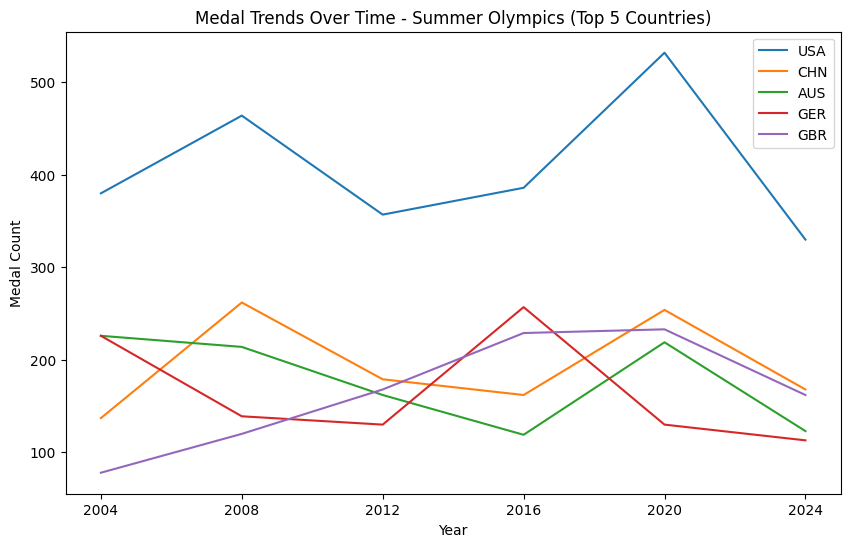

In [104]:
# Plot medal trends over time for the top 5 Summer countries
top_5_summer = summer_medal_counts.head(5)['noc'].tolist()
plt.figure(figsize=(10, 6))

for country in top_5_summer:
    country_data = summer_trends[summer_trends['noc'] == country]
    plt.plot(country_data['Year'], country_data['medal'], label=country)

plt.title('Medal Trends Over Time - Summer Olympics (Top 5 Countries)')
plt.xlabel('Year')
plt.ylabel('Medal Count')
plt.xticks(summer_trends['Year'].unique())
plt.legend()
plt.show()


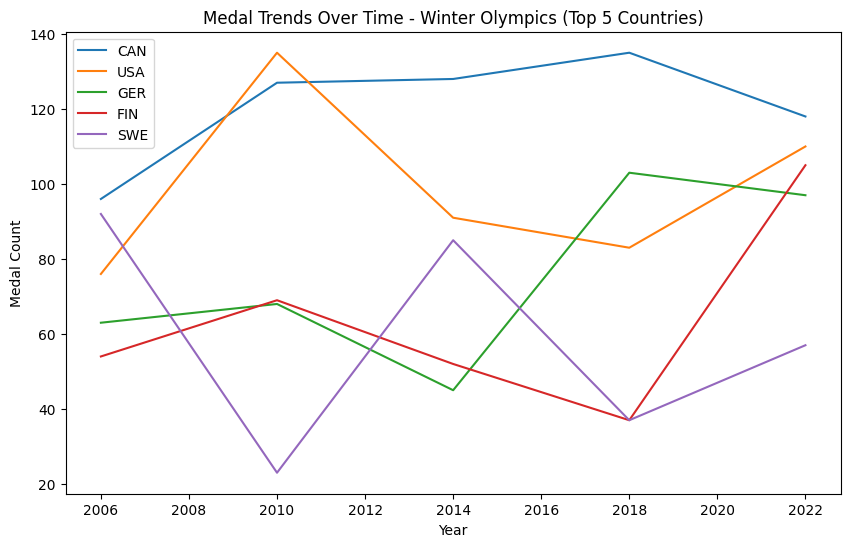

In [105]:
# Plot medal trends over time for the top 5 Winter countries
top_5_winter = winter_medal_counts.head(5)['noc'].tolist()
plt.figure(figsize=(10, 6))
for country in top_5_winter:
    country_data = winter_trends[winter_trends['noc'] == country]
    plt.plot(country_data['Year'], country_data['medal'], label=country)

plt.title('Medal Trends Over Time - Winter Olympics (Top 5 Countries)')
plt.xlabel('Year')
plt.ylabel('Medal Count')
plt.legend()
plt.show()
